# Project : Transaction Fraud Risk

**Which 500 Transactions Should the Fraud Team Check Today?**

IEEE-CIS / Vesta Corporation · 590,540 card payments · 3.5% fraud

---

**The problem.** A payments company gets ~100,000 card transactions a day.
Some are on stolen cards. Their fraud team can only review about 500.

So the question isn't "is this fraud?" It's **which 500 do they open first?**
It's a queue, and we're deciding the order.

**What we build.** A model that scores every transaction on fraud risk. Sort
by score, top 500 goes to the team.

If we allocate a team for checking into each fraud, the corporation would end up paying more to the audit team than the actual fraud amount

The answer at the end is one sentence, and it's about money:

> *"With 500 checks a day, we recover X% of the money lost to fraud."*

# Stage 0 : setup + loading

In [ ]:
# setting to max cols and rows for readability
import pandas as pd
import numpy as np

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',20)

## Importing Dataset
path = '/kaggle/input/competitions/ieee-fraud-detection/'
tx = pd.read_csv(path + 'train_transaction.csv')
idt = pd.read_csv(path + 'train_identity.csv')
print(tx.shape, idt.shape)

In [ ]:
# downcasting for low memory usage + no meaningful precision loss
def shrink(df):
 for c in df.select_dtypes('float64'):
     df[c] = pd.to_numeric(df[c], downcast='float')
 for c in df.select_dtypes('int64'):
     df[c] = pd.to_numeric(df[c], downcast='integer')
 return df
before = tx.memory_usage(deep=True).sum()/1e6
tx, idt = shrink(tx), shrink(idt)
print(before, '->', tx.memory_usage(deep=True).sum()/1e6, 'MB')


merging via left join (main table = transaction and TransactionID is the key)

In [ ]:
tx.columns = tx.columns.str.lower()
idt.columns = idt.columns.str.lower()
print(tx.columns)
idt.columns

**Some important Columns to Note**

Vesta published rough meanings, then anonymised the details.


* transactionamt payment amount in USD.
* productcd what was bought, coded. W, C, R, H, S.
* card1 to card6 card details. Type, category, issuing bank, country. card1 behaves like a card or bank identifier.
* addr1, addr2 billing region and country.
* dist1, dist2 distance. Likely billing address to shipping or IP location.
* p_emaildomain, r_emaildomain purchaser and recipient email domains.
* c1 to c14 counts. Things like how many addresses are linked to this card.
* d1 to d15 timedeltas. Days since some previous event on this card.
* m1 to m9 match flags. Does the name on the card match the address, and so on.
* v1 to v339 Vesta's own engineered features. Rankings, counts, entity relationships. anonymised features
* id_01 to id_38 network and device. IP, ISP, proxy, browser, OS, screen size.
* devicetype, deviceinfo phone or desktop, and the device string.


In [ ]:
df = tx.merge(idt,how= 'left',on = 'transactionid')
df.shape

In [ ]:
print(tx.shape)
idt.shape

In [ ]:
print('% of isfraud flags')
round(df.isfraud.value_counts(normalize = True)*100,2)

# Stage 1 : Splitting the dataset


In [ ]:
df.head(4)

**transactiondt**

* Time offset in seconds, not a calendar date
* Reference point was removed by Vesta before release
* 86,400 seconds = 1 day, so 86,400 = day 1, 172,800 = day 2, and so on
* Column runs 86,400 → 15,811,131, a 182-day window


So we will Split the dataset by ordering this temporal column and do a 80/20 split

In [ ]:
df = df.sort_values('transactiondt').reset_index(drop=True)
cut = int(len(df) * 0.8)
train, test = df.iloc[:cut].copy(), df.iloc[cut:].copy()
print(len(train), len(test), train.isfraud.mean(), test.isfraud.mean())
del df

# Stage 2: EDA 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

### missingness profile

In [ ]:
miss = train.isna().mean().sort_values(ascending = False)
print((miss >0.9).sum(), 'columns over 90% empty')


* 12 columns has almost 90% of the rows as NULL, We dont drop it yet, after checking the significance, we can come to a decision


### duplicate rows

In [ ]:
train.duplicated().sum()

* No duplicates found

### Checking Data types

In [ ]:
train.dtypes.value_counts()

In [ ]:
train.head(5)

##### below was .info() used to cross verify columns dtypes and values from above, DTYPES seems consistent

In [ ]:
# train.info(verbose=True,show_counts=True)

### checking outlier profile in numerical columns

In [ ]:
train.select_dtypes('number').skew().sort_values()

* High skewness for certain columns, presence of both EXTREMELY left and right skewed columns

In [ ]:
train.select_dtypes('number').describe()

* outliers in transactionalamt would make sense, could be an erorr or actual value
* the v columns have huge differences between its 75th percentile and max value -- should consider this ahead in further EDA

##### Basic preprocessing before univariate vizualizations

In [ ]:
# as discussed 86400 is day 1 
train['hour'] = (train.transactiondt // 3600) %24
train['dow'] = (train.transactiondt // 86400) % 7 
train['log_amt'] = np.log1p(train.transactionamt)

test['hour'] = (test.transactiondt // 3600) % 24
test['dow']  = (test.transactiondt // 86400) % 7
test['log_amt'] = np.log1p(test.transactionamt)

In [ ]:
train[['hour','dow','log_amt']]

**Transaction amount distribution — raw vs log**

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(12,4))

sns.histplot(train.transactionamt, bins = 100, ax=ax[0])
ax[0].set_title("trasactionamt-raw")

sns.histplot(train.log_amt,bins=100,ax=ax[1])
ax[1].set_title("log-amt")

plt.tight_layout()

**log_amt**

* transactionamt is heavily right-skewed — most transactions are small, a few very large
* log1p compresses the long tail, making the distribution readable and near-symmetric
* log1p not log, since log(0) is undefined
* Matters for linear models (Linear models are sensitive to skew and scale); trees are unaffected because log is monotonic (the scale never changes so tree models are unaffected)

**Class Balance**

In [ ]:
p1 = train.isfraud.value_counts().reset_index()
plt.pie(p1['count'],labels= p1.isfraud,autopct='%1.1f%%')
plt.title('Class distribution');

we have 3.5% of data points as fraud cases, so highly imbalanced dataset

**Fruad rate by hour**

In [ ]:
p2 = train.groupby('hour')['isfraud'].mean().reset_index()
sns.barplot(data = p2, x = 'hour',y='isfraud')

plt.axhline(train.isfraud.mean(), color='r', ls='--', label='baseline 3.5%')
plt.ylabel('fraud rate')
plt.title('Fraud rate by hour of day')
plt.legend()

* Hours 4-10 run 5x the fraud rate of hour 13
* Hour 0 is not midnight. The reference point is anonymised, so the offset is unknown
* Consistent across all rows, so the model can use it regardless

**Fraud Rate by DOW**

In [ ]:
p3 = train.groupby('dow')['isfraud'].mean().reset_index()
sns.barplot(data= p3, x = 'dow',y='isfraud')
plt.axhline(train.isfraud.mean(),color='r',ls = '--')

Day of the week doesnt really change the likelihood of fraud happening

**Share of all fraud by product**

In [ ]:
train[train.isfraud == 1].productcd.value_counts().plot(kind='pie',autopct='%.1f%%',title = 'share of all fraud by product');

most of the fraudulent activities are seen in the product ids : W and C amounting to 81.6% of total fraud combined

In [ ]:
card_cols = [i for i in train.columns if str(i).startswith('card')]
train[card_cols]

card 1-3 and 5 are anonymised -- but we can use card 4 and card6 which are readable

In [ ]:
fig,ax = plt.subplots(2,2,figsize=(12,6))
ax = ax.flatten()

sns.countplot(x='card4',data=train, ax = ax[0])
sns.countplot(x='card6',data=train, ax = ax[1])

sns.barplot(x= 'card4',y='isfraud',data=train,ax=ax[2])
sns.barplot(x= 'card6',y='isfraud',data=train,ax=ax[3])


**card4 (network) and card6 (type)**

* Volume is concentrated: visa ~305k, mastercard ~150k, discover and amex under 10k each
* Discover has the highest fraud rate at 7.4%, but on low volume, hence the wide confidence interval
* Visa and mastercard both sit at baseline (~3.5%); amex is slightly below at 2.9%
* Credit cards run 6.7% fraud vs 2.4% for debit, nearly 3x

**fraud by different email domains**
- but with some filters i.e.
     1. only including domains that has more than 500 rows, to remove noise
     2. showing total count of fraud by email domains
     3. showing mean share of fraud by the email domain 

In [ ]:
p4 = train.groupby('p_emaildomain')['isfraud'].agg(['size','sum','mean']).reset_index()
p4 = p4[p4['size']>500].sort_values(by='mean',ascending=True)


fig,ax1 = plt.subplots(figsize=(12,5))
sns.barplot(x='p_emaildomain',y='mean',data=p4,ax=ax1)
ax1.set_ylabel('fraud_rate')
ax1.tick_params(axis='x', rotation=45)

ax2= ax1.twinx()
sns.lineplot(x=range(len(p4)),y='sum',data=p4,ax=ax2, color='orange', marker='o')
ax2.set_ylabel('fraud_count -- yellow line')


plt.tight_layout();

* outlook.com has the highest fraud rate at 9.2%, nearly 3x the 3.5% baseline
* gmail.com sits at 4.4% but carries 8,039 frauds — 21x outlook's volume, need review here

**Checking cardinality**

In [ ]:
n = train.select_dtypes('object').nunique().sort_values(ascending=False)

plt.figure(figsize=(10,7))
sns.barplot(x=n.values, y=n.index)
plt.xlabel('unique values')

- Low cardinality (2–5 values) = one-hot

- High cardinality (60+ values) = frequency encoding, these columns are : deviceinfo, id_33, id_31, id_30, p_emaildomain, r_emaildomain.

**V-column correlation**

- we have so many v columns, we can drrop them based on how correlated they are with each other

In [ ]:
v = [c for c in train.columns if c.startswith('v')]
len(v)

- around 339 v columns

In [ ]:
# corr = train[v].corr()
# corr

In [ ]:
# !pip install feature-engine -q

# from feature_engine.selection import DropCorrelatedFeatures

# V = [c for c in train.columns if c.startswith('v')]

# dcf = DropCorrelatedFeatures(threshold=0.95)
# dcf.fit(train[V])

# drop_v = dcf.features_to_drop_
# print(len(V), 'v-columns ->', len(drop_v), 'redundant,', len(V) - len(drop_v), 'kept')
# print(len(dcf.correlated_feature_sets_), 'correlated groups found')

Commenting out above code and pasting its response to save time (for now, since limited by processing power)

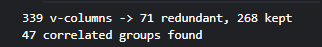

**V-column redundancy**

* 339 anonymised v-columns, many are near-duplicates
* Any pair above 0.95 correlation carries the same information twice
* Keep one per group, mark the rest as redundant
* Drop list is fitted on train and reused on test,never recomputed

**Nan_Bucket distribution with isfraud**

In [ ]:
train['nan_count'] = train.isna().sum(axis=1)
train['nan_bucket'] = pd.qcut(train.nan_count, 5, duplicates='drop')

In [ ]:
train.nan_bucket.value_counts()

In [ ]:
b = pd.qcut(train.nan_count, 5, duplicates='drop')
train.groupby(b, observed=True).isfraud.mean().plot(kind='bar')
plt.axhline(train.isfraud.mean(), color='r', ls='--')
plt.title('fraud rate by blanks per row')

* Each bar holds ~94k rows. qcut splits by count, so heights are comparable.
* Uneven x labels are fine. Bucket 3 spans 210 to 214, bucket 1 spans 26 to 133. Same rows in each.
* Red line is the 3.5% baseline.
* Only bucket 1 clears it, at 7.89%. Fewest blanks means most fraud.
* Middle bucket is lowest at 1.58%, under half the baseline.

**What it means**

* Fewer blanks means more metadata attached. Those channels get targeted more.

Channels = How the payment reached Vesta. The route it came through.

Examples:


* A phone app, which passes device ID
* A desktop browser checkout, which passes browser and device info
* Auto pay etc etc


**fraud rate by identity presence**

In [ ]:
for df in (train, test):
    df['has_id'] = df.id_01.notna().astype(int)

In [ ]:
sns.barplot(x=train.has_id, y=train.isfraud, errorbar=None)
plt.axhline(train.isfraud.mean(), color='r', ls='--')
plt.title('fraud rate by identity presence')

**Reading this plot**

* Red line is the 3.5% baseline.
* 0 means no identity data: 2.13% fraud, 74.5% of rows.
* 1 means identity attached: 7.55% fraud, 25.5% of rows.
* 3.5x lift. One of the strongest features before any engineering.
* Identity only gets captured on certain channels, and those channels are targeted more.

# Stage 3: Baseline modelling

In [ ]:
train

### Baseline 0

#### Position: we know our training data has 3.6% fraud, if we built a model that predicts each row as non fraud, we still get 96.5% accuracy

In [ ]:
# assume we built that model, the below will be its percentage for accuracy
print('Accuracy if all instances were predicted as negative: ',(round((train.isfraud == 0).mean(), 3)))

**WHY?**
1. To show even if we use model accuracy as the metric, we may get good results but it catches 0 fraud due to imbalanced target variable
2. This is why accuracy shouldnt be a metric here
3. Recall would make much sense as it focuses on False Negative (Missed Frauds/ Type II Errors)

### Baseline 1

#### Making a basic logistic regression with no feature engineering to have a base score

* We are taking most prominent features, according to the projects available on kaggle about the data as of now before we move on to a more comprehensive drill down in later stages

In [ ]:
num = ['transactionamt','addr1','hour','c1','c13','d1','v257']
cat = ['productcd','card4','card6','p_emaildomain','devicetype']
features = num + cat

X_train, y_train = train[features] , train['isfraud']
X_test, y_test = test[features] , test['isfraud']
print('done')

**Why these 12 columns**

* A baseline is meant to be small. 434 columns would hide whether the score comes from the model or from one lucky feature.
* `transactionamt`, `addr1`, `productcd`, `card4`, `card6`, `p_emaildomain`, `devicetype` are the interpretable block. Readable names, no anonymisation, easy to reason about.
* `hour` came out of EDA, 2.3% fraud at hour 13 against 10.6% at hour 7.
* `c1`, `c13`, `d1`, `v257` are stand-ins for the anonymised blocks. Commonly cited as the strongest in each group, so the baseline isn't blind to them.
* Everything here is raw. No engineering yet, so whatever the score is, it came from the data as given.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import TimeSeriesSplit, cross_validate

num_p = Pipeline([('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler())])

cat_p = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore',
                            sparse_output=False,
                            min_frequency=0.01))])

pre = ColumnTransformer([('num', num_p, num), ('cat', cat_p, cat)])

base = Pipeline([('pre', pre),
                 ('clf', LogisticRegression(max_iter=100, class_weight='balanced'))])

**Baseline 1: logistic regression, 12 columns.**

* Preprocessing sits inside the Pipeline, so it refits on every CV fold — no leakage
* min_frequency=0.01 : p_emaildomain has 59 values, most under 500 rows; rare ones collapse into one column
* class weight = balanced : sinve the classes are imbalanced

In [ ]:
cv = TimeSeriesSplit(n_splits=3)

res = cross_validate(base, X_train, y_train, cv=cv,
                     scoring=['average_precision','roc_auc','recall','precision'],
                     return_train_score=True)

print('PR-AUC      ', round(res['test_average_precision'].mean(), 4))
print('ROC-AUC     ', round(res['test_roc_auc'].mean(), 4))
print('recall      ', round(res['test_recall'].mean(), 4))
print('precision   ', round(res['test_precision'].mean(), 4))
print('train PR-AUC', round(res['train_average_precision'].mean(), 4))

**Baseline results, logistic regression on 12 columns**

| metric | score | what it means |
|---|---|---|
| PR-AUC | 0.2895 | precision and recall together, across every cutoff. Random here is 0.035, so about 8x lift |
| ROC-AUC | 0.7562 | given one real fraud and one real legit transaction, the fraud scores higher 76% of the time |
| recall | 0.6083 | of all actual frauds, 61% got flagged, measured at a 0.5 cutoff |
| precision | 0.107 | of everything flagged, 11% was real fraud. The other 89% was noise |
| train PR-AUC | 0.2171 | sits below the cv score, so nothing is overfitting. A linear model on 12 features underfits, which is what a baseline should do |

**Reading the numbers**

* ROC-AUC 0.7562 and PR-AUC 0.2895 come from the same predictions. That gap is the false positives ROC hides behind 455,833 negatives.
* Recall 0.61 with precision 0.107 is what `class_weight='balanced'` does. It flags aggressively, so the recall is bought with a queue that is 89% wrong.
* Recall and precision both depend on a 0.5 cutoff that nobody picked. Two models at different cutoffs can't be

# Stage 4 : Feature Engineering

Baseline sits at PR-AUC 0.2895 on 12 raw columns.
Everything below gets measured against that.

In [ ]:
def add_basic(df):
    df = df.copy()
    df['hour']      = (df.transactiondt // 3600) % 24
    df['day_index'] =  df.transactiondt // 86400
    df['log_amt']   = np.log1p(df.transactionamt)
    df['nan_count'] = df.isna().sum(axis=1)
    df['has_id']    = df.id_01.notna().astype(int)
    return df

train = add_basic(train)
test  = add_basic(test)

**Row level features**

* `hour` 2.3% fraud at hour 13, 10.6% at hour 7.
* `log_amt` amounts run 1 to 32,000. Log compresses the tail.
* `nan_count` blanks per row. 7.89% fraud in the fewest-blanks bucket, 1.58% in the middle.
* `has_id` 2.13% fraud without identity data, 7.55% with. 3.5x.

`day_index` is plumbing, not a feature. Dropped `dow` and `is_round`, both flat.

In [ ]:
def add_d1n(df):
    df = df.copy()
    df['d1n'] = df.day_index - df.d1
    return df

train = add_d1n(train)
test  = add_d1n(test)

**d1n**

* `d1` is days since the card first appeared. It climbs ~29 days across the training window, and test is later still, so a threshold learned on train drifts out of meaning.
* `day_index - d1` is the day the card first appeared. Fixed per card, no drift.


**logic**

* if a card holder has a mean of x amount, and spikes his usual spend amount for some n transactionid, this activity draws suspicion
* also the amt map is built via train set to avoid data leak

In [ ]:
num2 = ['transactionamt','addr1','hour','c1','c13','d1','v257',
        'log_amt','nan_count','has_id','d1n']
cat2 = ['productcd','card4','card6','p_emaildomain','devicetype']

**What changed from the baseline set**

* Added `log_amt`, `nan_count`, `has_id`, `d1n`. All row level, no dependency on history.
* Original 12 stay in, nothing swapped, so any score change comes from the additions alone.

In [ ]:
FEATURES2 = num2 + cat2

X_train2 = train[FEATURES2]
X_test2  = test[FEATURES2]

num_p2 = Pipeline([('imp', SimpleImputer(strategy='median')),
                   ('sc',  StandardScaler())])

cat_p2 = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                   ('ohe', OneHotEncoder(handle_unknown='ignore',
                                         sparse_output=False,
                                         min_frequency=0.01))])

pre2  = ColumnTransformer([('num', num_p2, num2), ('cat', cat_p2, cat2)])
base2 = Pipeline([('pre', pre2),
                  ('clf', LogisticRegression(max_iter=100, class_weight='balanced'))])

res2 = cross_validate(base2, X_train2, y_train, cv=cv,
                      scoring=['average_precision','roc_auc'])

print('PR-AUC ', round(res2['test_average_precision'].mean(), 4), '(was 0.2895)')
print('ROC-AUC', round(res2['test_roc_auc'].mean(), 4), '(was 0.7562)')

**Re-score**

| metric | baseline | + features 
|---|---|---|
| PR-AUC | 0.2895 | 0.2994 
| ROC-AUC | 0.7562 | 0.7616 
* PR-AUC up 0.0099, roughly 3.4%. 
* Boosters should get more from `nan_count` and `has_id` than logistic regression can, since neither relationship is linear.

# Stage 5: Model Training

Baseline is PR-AUC 0.2994 on 17 columns. Now open it up to the full feature set.
One model gives one talking point, several give a comparison.
Same CV object throughout, otherwise the comparison means nothing.

In [ ]:
!pip install feature_engine
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from feature_engine.selection import DropCorrelatedFeatures

In [ ]:
# V = [c for c in train.columns if c.startswith('v')]
# dcf = DropCorrelatedFeatures(threshold = 0.95)
# dcf.fit(train[V])
# drop_v = dcf.features_to_drop_

Commenting the code out and saving the result locally to save time

In [ ]:
# pd.DataFrame(drop_v).to_csv('drop_v.csv', index=False, header=['drop_columns'])
listy = pd.read_csv('drop_v.csv')
drop_v = listy.drop_columns.to_list()

In [ ]:
# now lets select features
drop = ['isfraud','transactionid','transactiondt','day_index','uid'] + list(drop_v)
ALL = [c for c in train.columns if c not in drop]

num_all = train[ALL].select_dtypes('number').columns.to_list()
cat_all = train[ALL].select_dtypes('object').columns.to_list()

X_train_all = train[num_all + cat_all]
X_test_all = test[num_all + cat_all]
print(len(drop_v), 'v-columns dropped |', len(num_all), 'numeric,', len(cat_all), 'categorical')

**Full feature set**

* The 17 column limit was a baseline design choice, to keep the score interpretable. Boosters have no such problem.
* `DropCorrelatedFeatures` fitted on train only, so the same drop list carries to test. Refitting it on test would be leak #2.
* Also dropped: the target, `transactionid` (an identifier that correlates with time), `transactiondt` (raw counter, replaced by `hour`), `day_index` 


In [ ]:
cat_t = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                  ('ord', OrdinalEncoder(handle_unknown='use_encoded_value',
                                         unknown_value=-1))])

pre_all = ColumnTransformer([('num', 'passthrough', num_all),
                             ('cat', cat_t, cat_all)])

**Why ordinal and not one-hot**

* Ordinal gives each category a number. `p_emaildomain` becomes one column with codes 0 to 58.
* One-hot gives each category its own column. Same feature becomes 59 columns. `deviceinfo` would become about 1,700.
* A tree can split once and grab a whole range of codes. With one-hot it needs a separate split for every single category, which wastes depth and gives weaker splits.
* The downside of ordinal is that it looks like an order, visa < mastercard < amex. That breaks linear models. Trees only ask "above or below this number", so it does not matter to them.
* `unknown_value=-1` handles categories that only show up in test, so nothing crashes.

One-hot for linear models, ordinal for trees.

**Two preprocessing paths**

* Linear models need imputing, scaling, one-hot. That is `pre2`.
* Trees need none of it. Scale is irrelevant since they split on thresholds, and one-hot fragments splits on high cardinality columns.

In [ ]:
# import time
# models = {
#     'logreg': (pre2,    X_train2,    LogisticRegression(max_iter=1000, class_weight='balanced')),
#     'tree':      (pre_all, X_train_all, DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42)),
#     'rf':        (pre_all, X_train_all, RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_leaf=5,
#                        n_jobs=-1, class_weight='balanced', random_state=42)),
#     'hgb':       (pre_all, X_train_all, HistGradientBoostingClassifier(random_state=42)),
# }

# results = {}
# for name, (prep, X, clf) in models.items():
#     t = time.time()
#     p = Pipeline([('pre', prep), ('clf', clf)])
#     r = cross_validate(p, X, y_train, cv=cv,
#                        scoring=['average_precision','roc_auc'],
#                        return_train_score=True, n_jobs=-1)
#     results[name] = {'cv_pr':    round(r['test_average_precision'].mean(), 4),
#                      'train_pr': round(r['train_average_precision'].mean(), 4),
#                      'cv_roc':   round(r['test_roc_auc'].mean(), 4),
#                      'secs':     round(time.time() - t, 1)}
#     print(name, results[name])

# ladder = pd.DataFrame(results).T.sort_values('cv_pr', ascending=False)
# ladder

In [ ]:
# import xgboost as xgb
# import time

# neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

# xgb_clf = xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=8,
#                             subsample=0.8, colsample_bytree=0.6,
#                             scale_pos_weight=neg/pos, eval_metric='aucpr',
#                             tree_method='hist', n_jobs=-1, random_state=42)

# t = time.time()
# p = Pipeline([('pre', pre_all), ('clf', xgb_clf)])
# r = cross_validate(p, X_train_all, y_train, cv=cv,
#                    scoring=['average_precision','roc_auc'],
#                    return_train_score=True, n_jobs=-1)

# results['xgb'] = {'cv_pr':    round(r['test_average_precision'].mean(), 4),
#                   'train_pr': round(r['train_average_precision'].mean(), 4),
#                   'cv_roc':   round(r['test_roc_auc'].mean(), 4),
#                   'secs':     round(time.time() - t, 1)}

# ladder = pd.DataFrame(results).T.sort_values('cv_pr', ascending=False)
# ladder

* Full feature set took the score from 0.2994 to 0.5502, roughly 16x random (0.035 here).
* XGBoost tops PR-AUC by 0.0067, which is inside noise, while sitting at 0.985 on train against HGB's 0.820. HGB also wins ROC-AUC outright.
* Shipping HGB. It is native to sklearn, no extra dependency, same runtime, and far less overfit for a 1.2% difference on one metric.
* logreg is the only model where cv beats train. A linear model on 17 columns cannot memorise 472k rows.

In [ ]:
best = Pipeline([('pre', pre_all),
                 ('clf', HistGradientBoostingClassifier(random_state=42))])
best.fit(X_train_all, y_train)

proba = best.predict_proba(X_test_all)[:, 1]

from sklearn.metrics import average_precision_score, roc_auc_score
print('test PR-AUC ', round(average_precision_score(y_test, proba), 4))
print('test ROC-AUC', round(roc_auc_score(y_test, proba), 4))

**Reading the score**

The model scores every transaction on how likely it is to be fraud, then sorts them. Fraud is 3.5% of all transactions, so picking at random you'd be right 3.5% of the time. The model is about 16 times better than that at putting real fraud at the top of the list.

That's how good the sorting is. Next is what it's worth in money.

# Stage 6: Threshold Economics

The test set gets touched once, here. Everything before this ran on train only.

0.5 is a library default, not a decision. The team reviews 500 a day, so the question is which 500.

In [ ]:
res = test.copy()
res['confidence'] = proba
res['expected_value'] = res.confidence * res.transactionamt

total_fraud_amount = res.loc[res.isfraud ==1,'transactionamt'].sum()
print('total fraud value in test: $', round(total_fraud_amount))

* `confidence` the model's score, 0 to 1.
* `expected_value` confidence times amount. Money at risk on this transaction.
* `total_fraud_amount` all the fraud money in the test window. The denominator for everything below.

**Naive attempt with just taking highest confidence**

In [ ]:
top500 = res.nlargest(500, 'confidence')

print('frauds caught  ', top500.isfraud.sum())
print('precision      ', round(top500.isfraud.mean(), 3))
print('money recovered', round(top500[top500.isfraud == 1].transactionamt.sum() / total_fraud_amount, 3))

In [ ]:
best_possible = res[res.isfraud == 1].nlargest(500, 'transactionamt').transactionamt.sum() / total_fraud_amount
print('Assuming a perfect model taking out 500 rows the recovery percentage will be:', round(best_possible, 3)*100,'%')

In [ ]:
len(test[test.isfraud ==1])

**The ceiling**

* There are 4,064 fraudulent transactions and only 500 reviews. Even a perfect model cannot catch them all.
* An oracle that knows every fraud and picks the 500 biggest recovers 53.7%.
* That is the number to judge against, not 100%.

In [ ]:
by_prob  = res.nlargest(500, 'confidence')
by_money = res.nlargest(2000, 'confidence').nlargest(500, 'transactionamt')
by_ev    = res.nlargest(500, 'expected_value')


for name, t in [('by probability', by_prob), ('by money', by_money),
                ('by expected value', by_ev)]:
    print(name,
          '| frauds', t.isfraud.sum(),
          '| precision', round(t.isfraud.mean(), 3),
          '| money', round(((t[t.isfraud == 1].transactionamt.sum() / total_fraud_amount)*100),3),'%')


* Sorting by confidence catches the most frauds but the cheapest ones.
  
* Sorting by confidence times amount recovers 3x the money. Fewer real frauds, but each is worth more. (EV)
  
* A 0.4 score on a USD 2,000 transaction is USD 800 at risk. A 0.99 on a USD 60 one is USD 59. The queue should be sorted by money at risk.
 
* Which to ship is a business call, not a modelling one. Chargeback losses means expected value. Account compromises means probability.

In [ ]:
def money_back(t):
    return t[t.isfraud == 1].transactionamt.sum() / total_fraud_amount

ks = range(100, 5001, 250)
plt.plot(ks, [money_back(res.nlargest(k, 'confidence')) for k in ks], label='by probability')
plt.plot(ks, [money_back(res.nlargest(k, 'expected_value')) for k in ks], label='by expected value')
plt.xlabel('reviews per day')
plt.ylabel('fraud money recovered')
plt.legend()

* Expected value ranking wins at every budget, not just at 500.

# Stage 7: Fraud Analysis Dashboard

In [ ]:
out = test[['transactionid','transactionamt','isfraud','productcd','card4','card6','devicetype','hour']].copy()
out['confidence']     = proba
out['expected_value'] = out.confidence * out.transactionamt

out['in_top500_prob'] = out.transactionid.isin(by_prob.transactionid).astype(int)
out['in_top500_ev']   = out.transactionid.isin(by_ev.transactionid).astype(int)

out.to_csv('bi_data.csv', index=False)
out.head()

**Export for the dashboard**

* One row per test transaction with score, expected value, and which strategy picked it.
* Two flags so the dashboard can toggle between strategies with a slicer.
* Slicer dimensions included: product, card network, card type, device, hour.

**Headline**

At 500 reviews a day, ranking by expected value recovers 22.2% of fraud value at 47% precision,
against a ceiling of 53.7% for a perfect model at the same budget.
Ranking by probability alone recovers 7.1% at 92% precision.